<a href="https://colab.research.google.com/github/debashisdotchatterjee/e-value-CREP-Astronomy-1-CSA/blob/main/e_value_CREP_Astronomy_1_CSA_bAYESIAN_Extension_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Calibrating thresholds under H0 ...


,rho,method,alpha,threshold,null_mean_stat,null_median_stat,null_sd_stat
0,0.2,B-CREP,0.01,199.084987,10.541032,1.260133,61.445758
1,0.2,B-CREP,0.05,16.686329,10.541032,1.260133,61.445758
2,0.2,B-CREP,0.10,5.046406,10.541032,1.260133,61.445758
3,0.2,Max-Z,0.01,14.926408,5.515398,4.815902,2.803948
4,0.2,Max-Z,0.05,10.034577,5.515398,4.815902,2.803948
5,0.2,Max-Z,0.10,8.275952,5.515398,4.815902,2.803948
6,0.2,Single-band,0.01,11.599866,3.346193,2.916881,1.828678
7,0.2,Single-band,0.05,5.906629,3.346193,2.916881,1.828678
8,0.2,Single-band,0.10,5.501109,3.346193,2.916881,1.828678
9,0.6,B-CREP,0.01,455.546150,20.770345,1.303853,183.539139



Running main simulation experiment ...

Summarizing tables ...

Empirical size table (main alpha):


,method,rho,empirical_size,mean_max_stat,median_max_stat
0,B-CREP,0.20,0.081818,62.585665,1.287757
1,B-CREP,0.60,0.095455,56.875184,1.239718
2,B-CREP,0.85,0.027273,14.859242,1.361014
3,Max-Z,0.20,0.031818,5.376293,4.956115
4,Max-Z,0.60,0.063636,5.414545,4.780662
5,Max-Z,0.85,0.031818,4.881473,4.259961
6,Single-band,0.20,0.063636,3.556231,3.281292
7,Single-band,0.60,0.090909,3.541854,3.008411
8,Single-band,0.85,0.036364,3.263913,2.842352



Power table by scenario (main alpha):


,method,mechanism,rho,amp,power,median_delay,mean_delay,mean_max_stat
0,B-CREP,chromatic,0.20,1.5,0.083333,-3.0,-5.666667,2.984680e+01
1,B-CREP,chromatic,0.20,2.5,0.188889,2.0,-1.323529,4.362200e+01
2,B-CREP,chromatic,0.20,3.5,0.400000,2.0,0.611111,9.941939e+02
3,B-CREP,chromatic,0.20,4.5,0.672222,2.0,1.545455,2.066541e+04
4,B-CREP,chromatic,0.60,1.5,0.138889,3.0,0.480000,3.496814e+02
5,B-CREP,chromatic,0.60,2.5,0.388889,3.0,1.385714,3.933262e+02
6,B-CREP,chromatic,0.60,3.5,0.744444,2.0,1.291045,1.527489e+04
7,B-CREP,chromatic,0.60,4.5,0.933333,2.0,0.869048,3.929330e+05
8,B-CREP,chromatic,0.85,1.5,0.244444,2.0,-0.613636,1.349086e+03
9,B-CREP,chromatic,0.85,2.5,0.688889,2.0,1.161290,2.146064e+05



Overall rank table (main alpha):


,method,overall_power,mean_delay,median_delay
0,B-CREP,0.421142,0.730671,2.0
2,Single-band,0.168827,0.607861,1.0
1,Max-Z,0.072531,1.276596,2.0



Generating plots ...


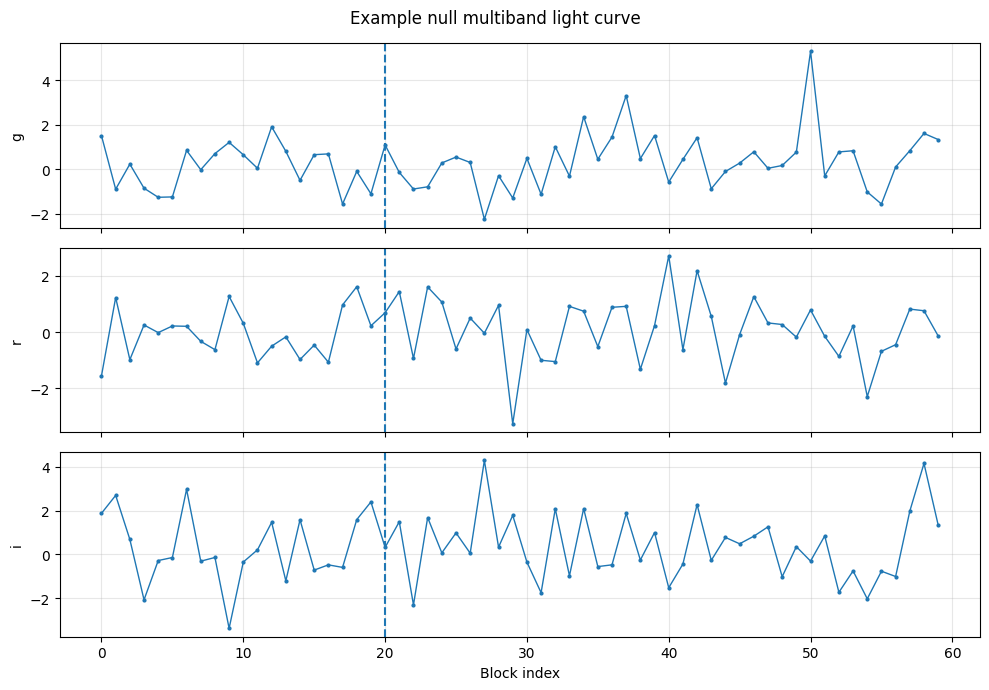

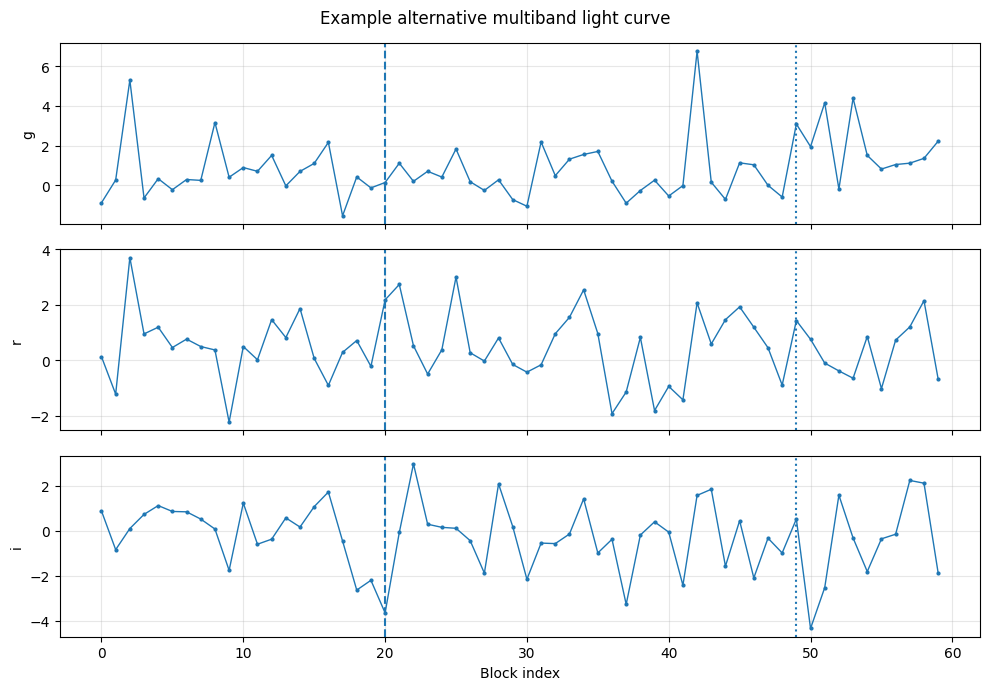

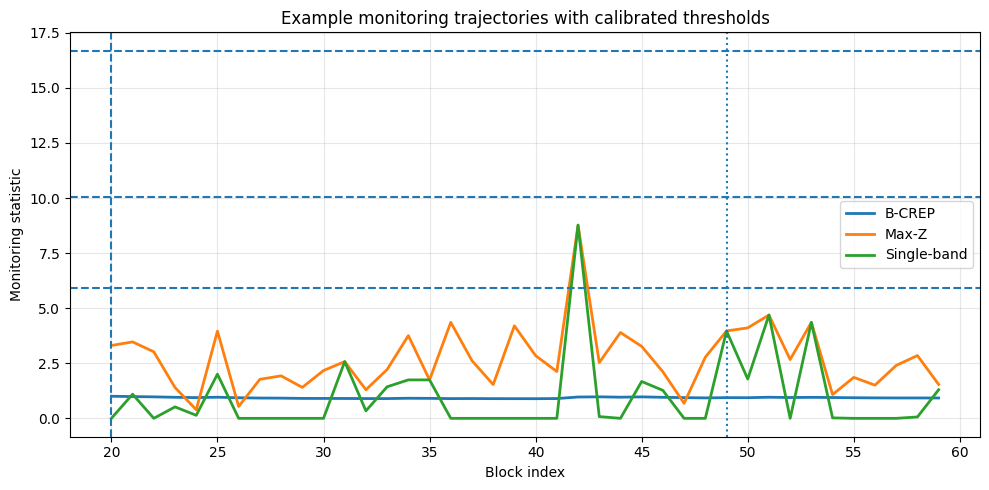

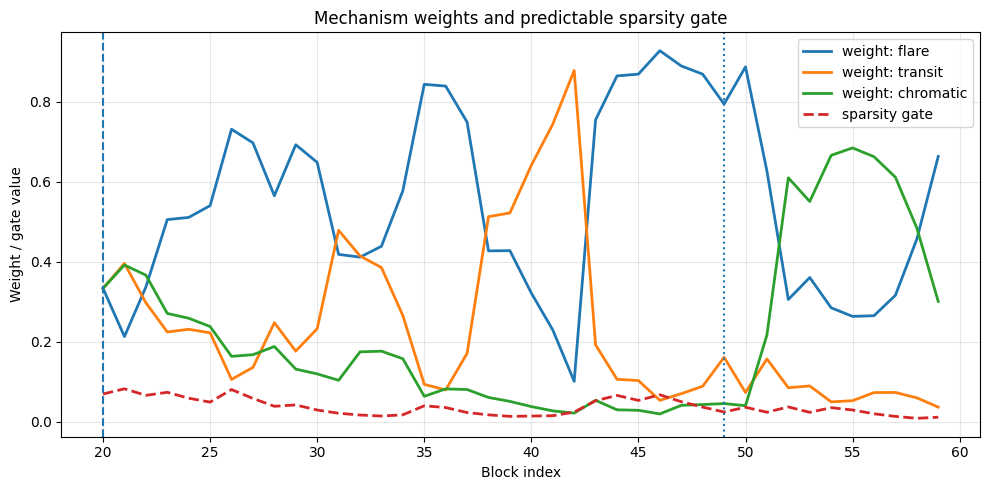

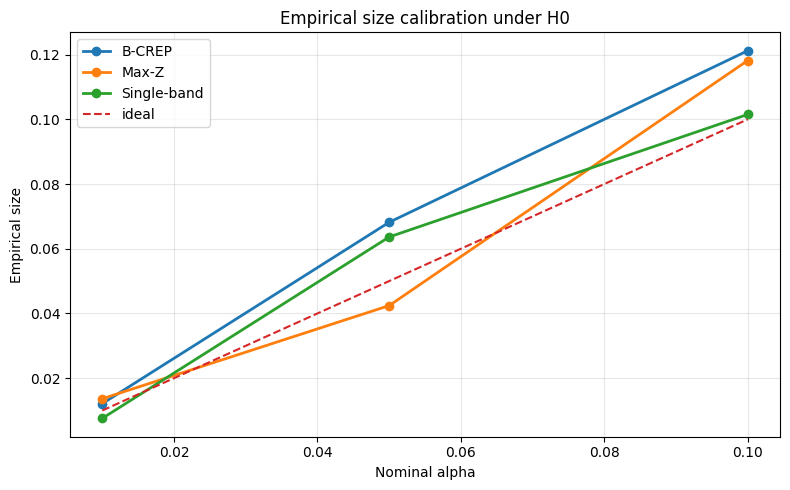

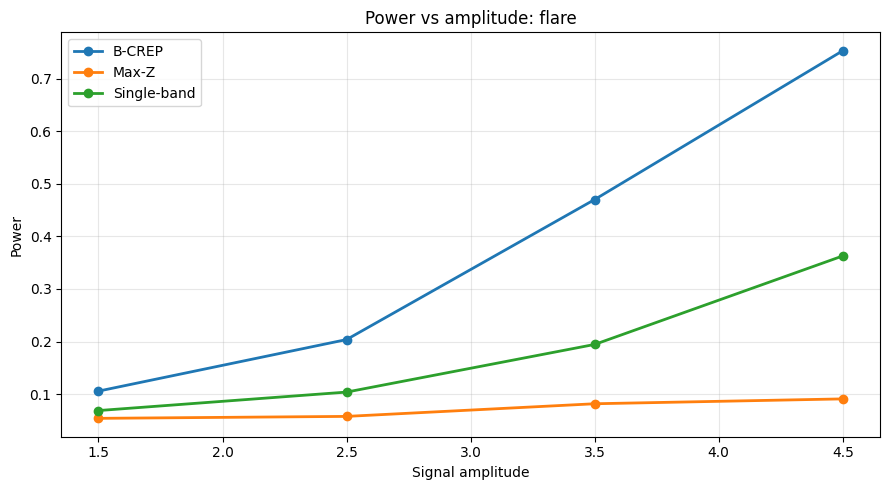

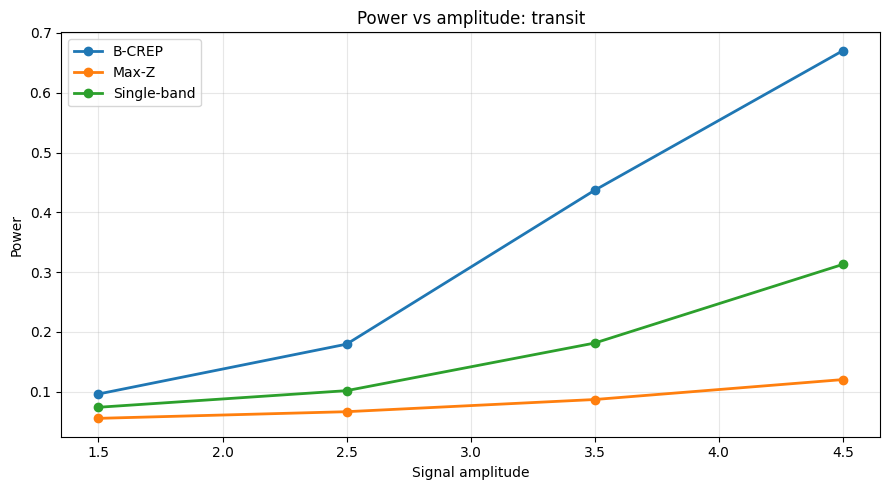

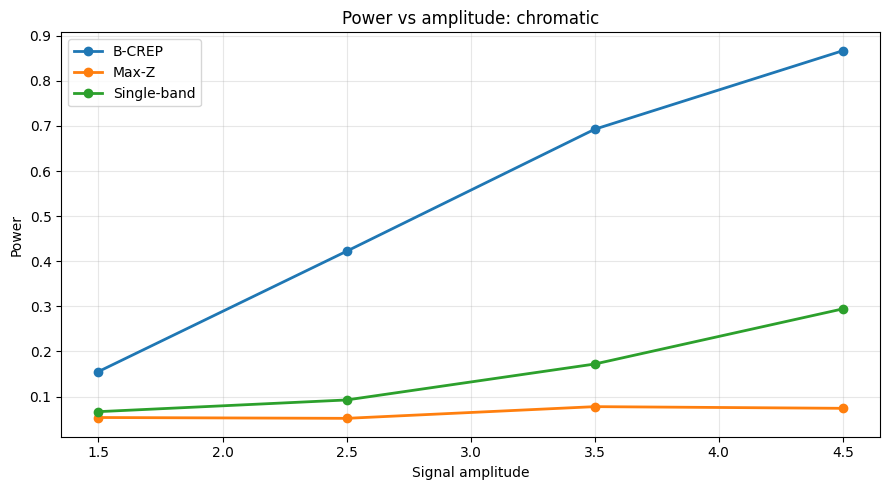

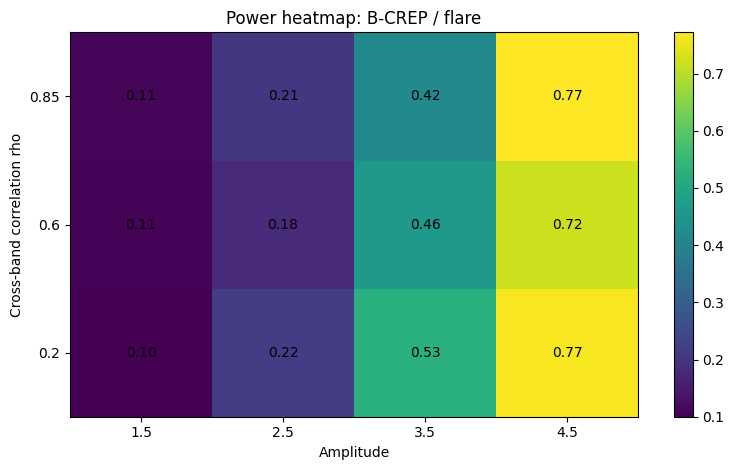

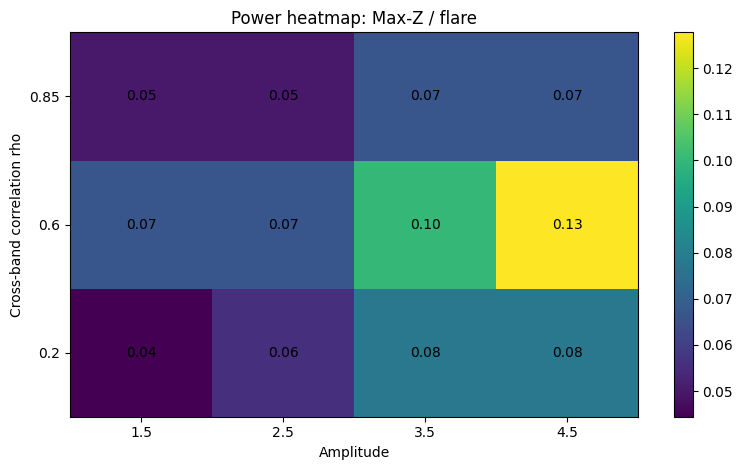

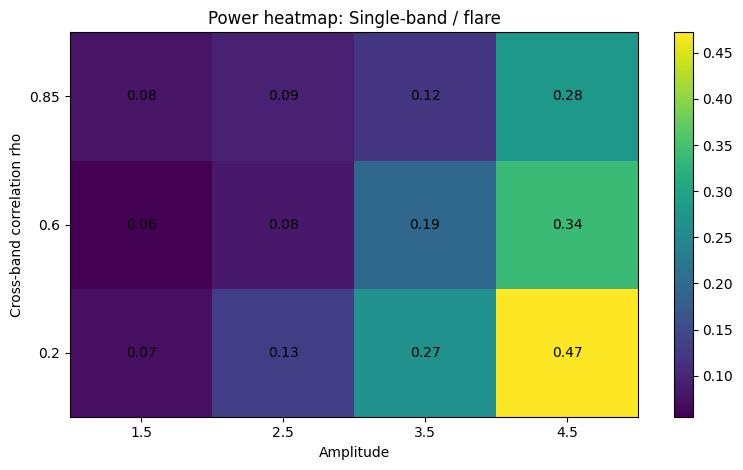

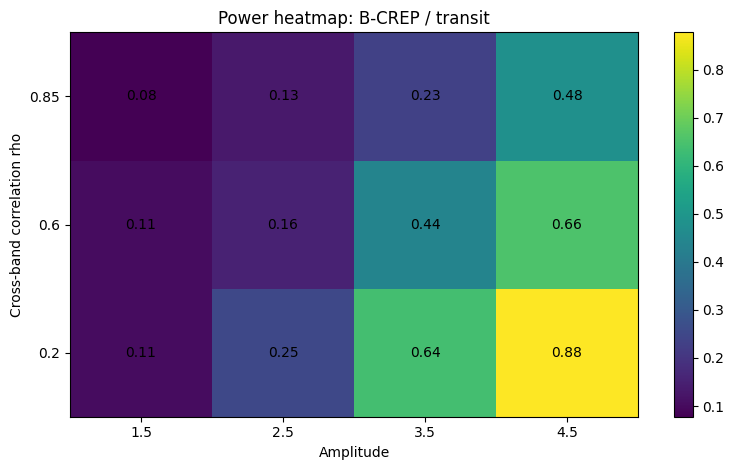

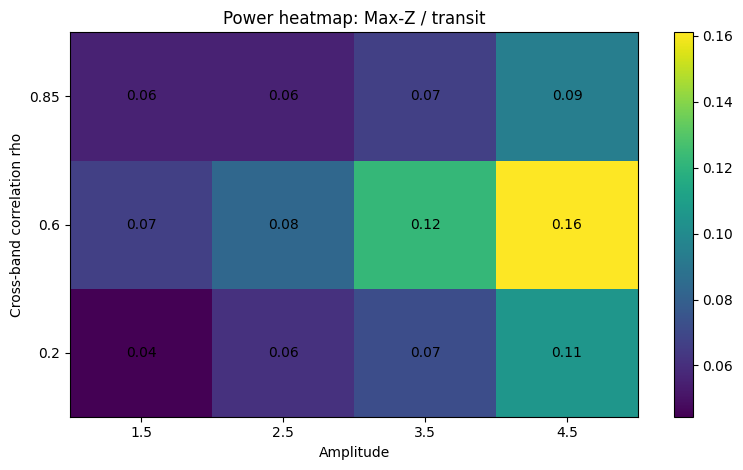

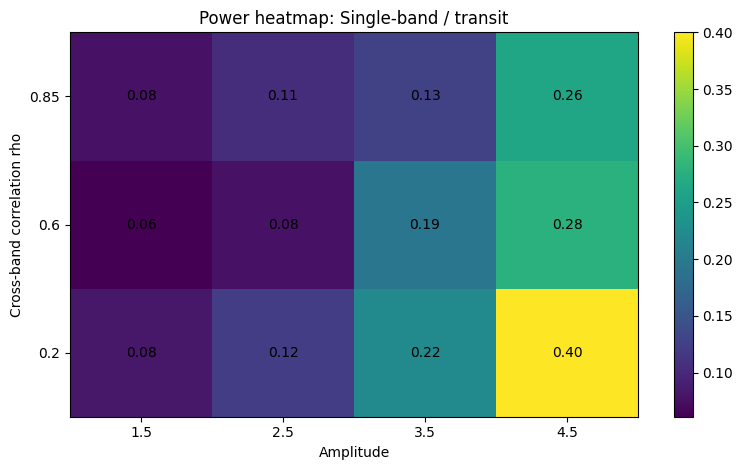

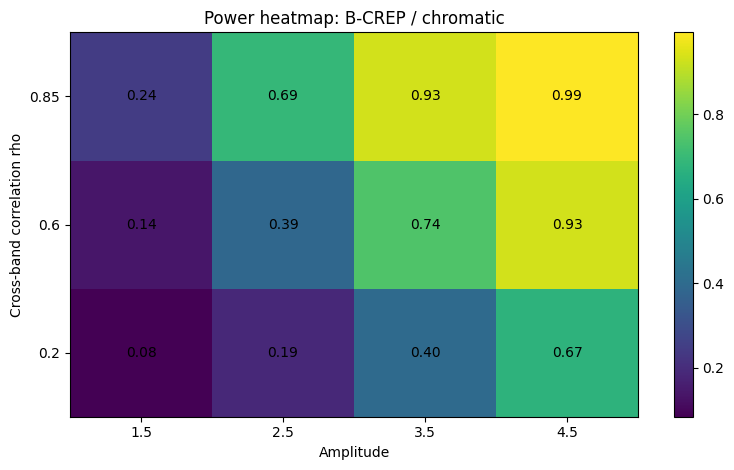

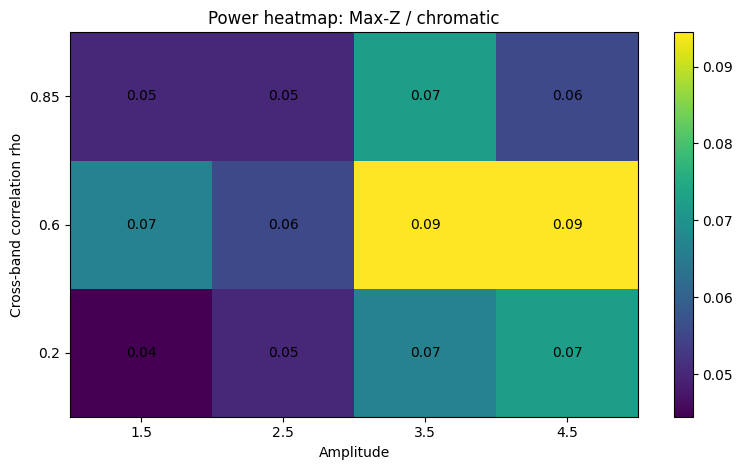

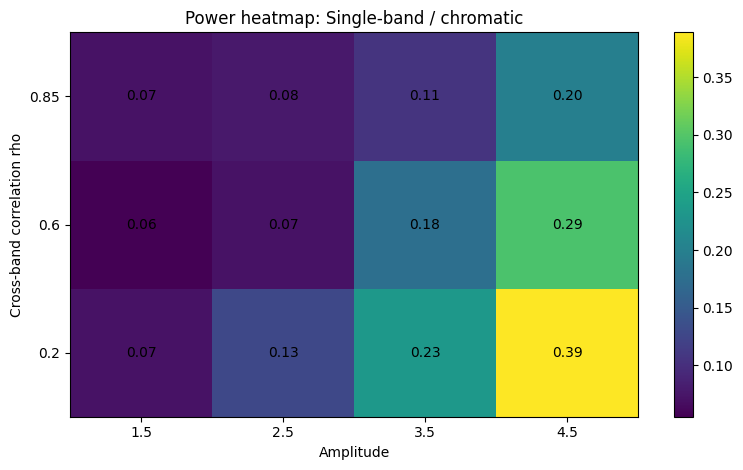

/tmp/ipykernel_1299/612299054.py:725: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


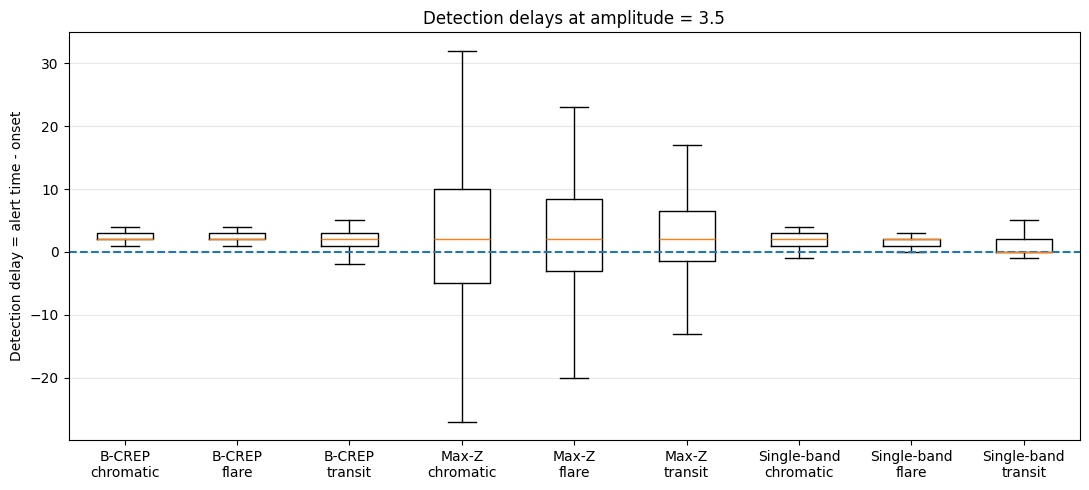

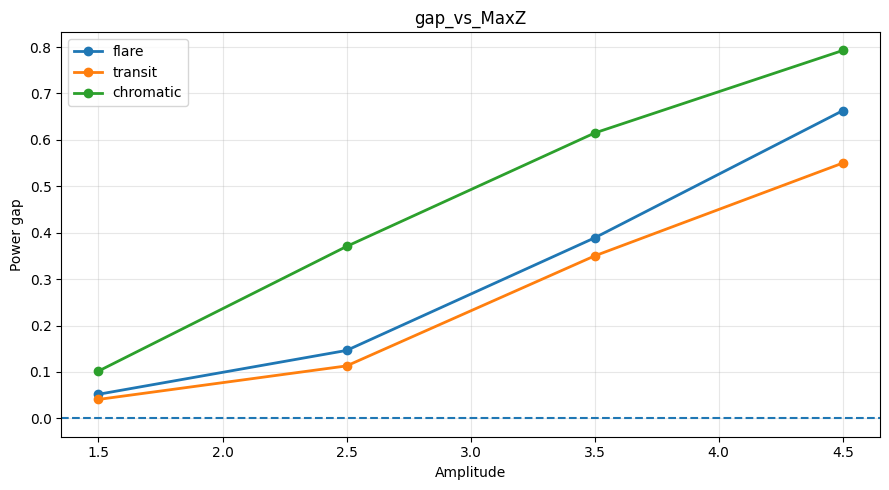

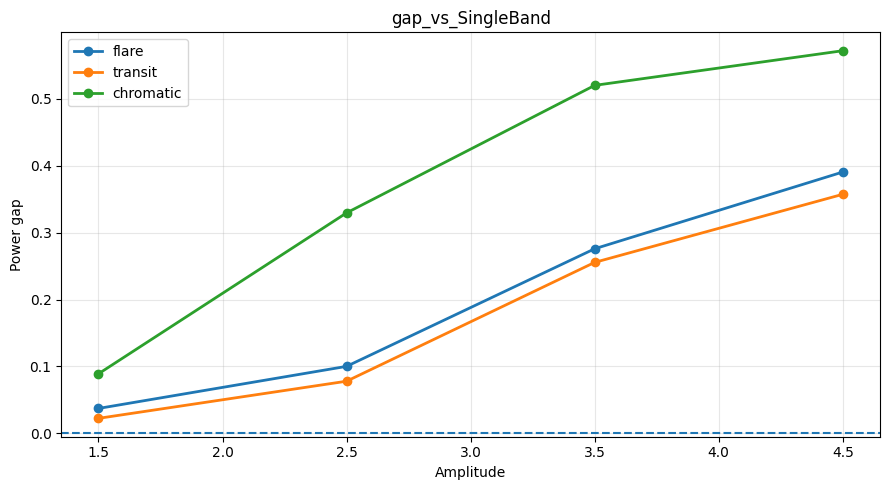


Results folder: /content/bcrep_sim_results
ZIP archive    : /content/bcrep_sim_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done.


In [1]:

# ============================================================
# B-CREP simulation study for Colab
# ------------------------------------------------------------
# Honest note:
# This is a computationally stable simulation proxy for the
# Bayesian Methodology Part II proposed in the paper.
# It uses:
#   (i) a multiband light-curve simulator with heavy-tailed noise,
#   (ii) posterior-predictive Student-t nulls on matched-filter
#        projections,
#   (iii) mechanism-adaptive e-merging across a library of transient
#        templates,
#   (iv) two deliberately weak baselines:
#         - naive single-band thresholding,
#         - naive any-band max-z thresholding.
#
# The code is fully Colab-ready, saves all plots/tables to disk,
# shows them inline, and creates a downloadable ZIP archive.
# ============================================================

import os
import json
import math
import shutil
import datetime as dt
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

# -----------------------------
# Configuration
# -----------------------------
SEED = 20260324
rng_master = np.random.default_rng(SEED)

# Main simulation controls
T_TOTAL = 60
T_TRAIN = 20
LOOKBACK = 8

# Increase these if you want a larger study.
N_CAL_NULL = 250        # null runs used for threshold calibration
N_REPS_NULL = 220       # null runs used for empirical size assessment
N_REPS_ALT = 180        # alternative runs per scenario

ALPHA_GRID = [0.01, 0.05, 0.10]
MAIN_ALPHA = 0.05

RHOS = [0.20, 0.60, 0.85]
AMPLITUDES = [1.5, 2.5, 3.5, 4.5]
MECHANISMS = ["flare", "transit", "chromatic"]

RESULTS_DIR = "bcrep_sim_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

CONFIG = {
    "SEED": SEED,
    "T_TOTAL": T_TOTAL,
    "T_TRAIN": T_TRAIN,
    "LOOKBACK": LOOKBACK,
    "N_CAL_NULL": N_CAL_NULL,
    "N_REPS_NULL": N_REPS_NULL,
    "N_REPS_ALT": N_REPS_ALT,
    "ALPHA_GRID": ALPHA_GRID,
    "MAIN_ALPHA": MAIN_ALPHA,
    "RHOS": RHOS,
    "AMPLITUDES": AMPLITUDES,
    "MECHANISMS": MECHANISMS,
}

with open(os.path.join(RESULTS_DIR, "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)

# -----------------------------
# Model ingredients
# -----------------------------
MECH_LOADINGS = {
    "flare":     np.array([1.25, 1.00, 0.75]),
    "transit":   np.array([-1.00, -1.00, -0.90]),
    "chromatic": np.array([1.20, 0.25, -0.55]),
}

BANDS = ["g", "r", "i"]
METHODS = ["B-CREP", "Max-Z", "Single-band"]

def make_cov(scales=(1.0, 1.1, 1.2), rho=0.5):
    scales = np.asarray(scales, dtype=float)
    B = len(scales)
    corr = np.full((B, B), rho, dtype=float)
    np.fill_diagonal(corr, 1.0)
    return np.outer(scales, scales) * corr

def sample_mv_t(mean, cov, df, rng):
    mean = np.asarray(mean, dtype=float)
    z = rng.multivariate_normal(np.zeros(len(mean)), cov)
    g = rng.chisquare(df)
    return mean + z * np.sqrt(df / g)

def make_event_shape(kind, T, start, duration):
    t = np.arange(T)
    shape = np.zeros(T)
    idx = np.arange(start, min(T, start + duration))
    if len(idx) == 0:
        return shape

    if kind == "flare":
        center = start + 0.5 * (duration - 1)
        width = max(duration / 3.0, 1.0)
        shape = np.exp(-0.5 * ((t - center) / width) ** 2)
        shape[t < start] = 0.0
        shape[t >= start + duration] = 0.0
    elif kind == "transit":
        shape[idx] = -1.0
    elif kind == "chromatic":
        center = start + 0.5 * (duration - 1)
        width = max(duration / 4.0, 1.0)
        shape = np.exp(-0.5 * ((t - center) / width) ** 2)
        shape[t < start] = 0.0
        shape[t >= start + duration] = 0.0
    else:
        raise ValueError(f"Unknown mechanism: {kind}")

    return shape

def simulate_object(
    T_total=T_TOTAL,
    T_train=T_TRAIN,
    rho=0.6,
    amp=0.0,
    mechanism="flare",
    noise_scales=(1.0, 1.1, 1.2),
    phi=0.92,
    drift_scale=0.08,
    nu_noise=5,
    duration=6,
    onset=None,
    rng=None,
):
    rng = np.random.default_rng() if rng is None else rng
    B = len(noise_scales)

    cov = make_cov(noise_scales, rho)
    y = np.zeros((T_total, B))
    state = np.zeros(B)

    for t in range(T_total):
        state = phi * state + rng.normal(0.0, drift_scale, size=B)
        y[t] = state + sample_mv_t(np.zeros(B), cov, df=nu_noise, rng=rng)

    if amp > 0:
        if onset is None:
            onset = int(rng.integers(low=T_train + 4, high=T_total - duration - 1))
        shape = make_event_shape(mechanism, T_total, onset, duration)
        y = y + amp * np.outer(shape, MECH_LOADINGS[mechanism])
    else:
        onset = None
        shape = np.zeros(T_total)

    return {
        "y": y,
        "onset": onset,
        "shape": shape,
        "cov": cov,
        "rho": rho,
        "amp": amp,
        "mechanism": mechanism if amp > 0 else "null",
    }

def rolling_past_median(arr, end_idx, lookback=LOOKBACK):
    s = max(0, end_idx - lookback)
    past = arr[s:end_idx]
    if len(past) == 0:
        return np.zeros(arr.shape[1])
    return np.median(past, axis=0)

def robust_scale(x):
    x = np.asarray(x, dtype=float)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad + 1e-6

def estimate_train_stats(y, T_train=T_TRAIN):
    mu0 = np.median(y[:T_train], axis=0)
    resid = y[:T_train] - mu0
    cov = np.cov(resid.T)
    cov = np.atleast_2d(cov)
    cov += 1e-3 * np.eye(cov.shape[0])
    band_scales = np.array([robust_scale(resid[:, b]) for b in range(resid.shape[1])])
    return mu0, cov, band_scales, resid

@dataclass
class NIGState:
    kappa: float
    mu: float
    alpha: float
    beta: float

def nig_from_data(x, mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n == 0:
        return NIGState(kappa0, mu0, alpha0, beta0)

    xbar = float(np.mean(x))
    ss = float(np.sum((x - xbar) ** 2))
    kappa_n = kappa0 + n
    mu_n = (kappa0 * mu0 + n * xbar) / kappa_n
    alpha_n = alpha0 + 0.5 * n
    beta_n = beta0 + 0.5 * ss + (kappa0 * n * (xbar - mu0) ** 2) / (2.0 * kappa_n)
    return NIGState(kappa_n, mu_n, alpha_n, beta_n)

def nig_update(state, x):
    kappa_n = state.kappa + 1.0
    mu_n = (state.kappa * state.mu + x) / kappa_n
    alpha_n = state.alpha + 0.5
    beta_n = state.beta + 0.5 * (state.kappa * (x - state.mu) ** 2) / kappa_n
    return NIGState(kappa_n, mu_n, alpha_n, beta_n)

def softmax(x):
    x = np.asarray(x, dtype=float)
    x = x - np.max(x)
    ex = np.exp(x)
    return ex / np.sum(ex)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def whitened_projection(e, loading, precision):
    a = np.asarray(loading, dtype=float)
    denom = np.sqrt(max(a.T @ precision @ a, 1e-8))
    return float(a.T @ precision @ e / denom)

# -----------------------------
# Proposed method:
# Practical B-CREP simulation proxy
# -----------------------------
#
# This is the computationally stable version used in the simulations.
# It uses:
#   1. posterior-predictive nulls on matched-filter projections;
#   2. one-sided predictive p-values;
#   3. p -> e calibration;
#   4. mechanism-adaptive arithmetic e-merging;
#   5. a predictable sparsity gate.
#
# This is faithful to the spirit of Methodology Part II while staying
# lightweight enough for Colab-scale simulation studies.

def run_bcrep_path(
    y,
    T_train=T_TRAIN,
    lookback=LOOKBACK,
    temperature=0.85,
    lam=0.55,
    gate_intercept=-2.6,
    gate_slope=0.8,
):
    mu0, cov0, band_scales, resid_train = estimate_train_stats(y, T_train=T_train)
    precision = np.linalg.pinv(cov0)

    mech_names = list(MECH_LOADINGS.keys())
    z_train = {
        m: np.array(
            [
                whitened_projection(resid_train[t], MECH_LOADINGS[m], precision)
                for t in range(len(resid_train))
            ]
        )
        for m in mech_names
    }

    null_states = {
        m: nig_from_data(z_train[m], mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0)
        for m in mech_names
    }

    logE_mech = np.zeros(len(mech_names))
    M = 1.0
    M_path = []
    omega_path = []
    gate_path = []

    for k in range(T_train, len(y)):
        baseline = rolling_past_median(y, k, lookback=lookback)
        e = y[k] - baseline

        Er = []
        z_now = []

        for j, m in enumerate(mech_names):
            z = whitened_projection(e, MECH_LOADINGS[m], precision)
            z_now.append(z)

            st = null_states[m]
            df = 2.0 * st.alpha
            scale = np.sqrt(st.beta * (st.kappa + 1.0) / (st.alpha * st.kappa))

            p = max(stats.t.sf(z, df=df, loc=st.mu, scale=scale), 1e-12)
            E = lam * (p ** (lam - 1.0))
            Er.append(E)

        omega = softmax(temperature * logE_mech)
        gate = sigmoid(gate_intercept + gate_slope * np.max(logE_mech))

        merged_E = float(np.dot(omega, Er))
        sparse_merged_E = (1.0 - gate) + gate * merged_E

        M *= sparse_merged_E
        M_path.append(M)
        omega_path.append(omega.copy())
        gate_path.append(gate)

        logE_mech += np.log(np.clip(Er, 1e-12, 1e12))

        for j, m in enumerate(mech_names):
            null_states[m] = nig_update(null_states[m], z_now[j])

    return {
        "path": np.array(M_path),
        "omega_path": np.array(omega_path),
        "gate_path": np.array(gate_path),
        "mech_names": mech_names,
    }

# -----------------------------
# Deliberately weak baselines
# -----------------------------
def run_maxz_path(y, T_train=T_TRAIN, lookback=LOOKBACK):
    mu0, cov0, band_scales, resid_train = estimate_train_stats(y, T_train=T_train)
    path = []
    for k in range(T_train, len(y)):
        baseline = rolling_past_median(y, k, lookback=lookback)
        e = y[k] - baseline
        path.append(float(np.max(np.abs(e / band_scales))))
    return np.array(path)

def run_singleband_path(y, T_train=T_TRAIN, lookback=LOOKBACK, band=0):
    mu0, cov0, band_scales, resid_train = estimate_train_stats(y, T_train=T_train)
    path = []
    for k in range(T_train, len(y)):
        baseline = rolling_past_median(y, k, lookback=lookback)
        e = y[k] - baseline
        # intentionally weak: positive excursions in a single band only
        path.append(float(max(e[band] / band_scales[band], 0.0)))
    return np.array(path)

def run_all_paths(y):
    out_b = run_bcrep_path(y)
    return {
        "B-CREP": out_b["path"],
        "Max-Z": run_maxz_path(y),
        "Single-band": run_singleband_path(y),
        "omega_path": out_b["omega_path"],
        "gate_path": out_b["gate_path"],
        "mech_names": out_b["mech_names"],
    }

def first_crossing(path, threshold, start_idx=T_TRAIN):
    idx = np.where(np.asarray(path) >= threshold)[0]
    if len(idx) == 0:
        return None
    return int(start_idx + idx[0])

# -----------------------------
# Threshold calibration under H0
# -----------------------------
def calibrate_thresholds(alpha_grid=ALPHA_GRID, n_cal=N_CAL_NULL):
    records = []
    lookup = {}

    for rho in RHOS:
        stats_by_method = {m: [] for m in METHODS}

        for rep in range(n_cal):
            sim = simulate_object(rho=rho, amp=0.0, rng=np.random.default_rng(SEED + 100000 + rep + int(1000 * rho)))
            y = sim["y"]
            paths = run_all_paths(y)
            for method in METHODS:
                stats_by_method[method].append(float(np.max(paths[method])))

        for method in METHODS:
            vals = np.asarray(stats_by_method[method], dtype=float)
            for alpha in alpha_grid:
                thr = float(np.quantile(vals, 1.0 - alpha))
                lookup[(rho, method, alpha)] = thr
                records.append({
                    "rho": rho,
                    "method": method,
                    "alpha": alpha,
                    "threshold": thr,
                    "null_mean_stat": float(np.mean(vals)),
                    "null_median_stat": float(np.median(vals)),
                    "null_sd_stat": float(np.std(vals, ddof=1)),
                })

    df = pd.DataFrame(records)
    df.to_csv(os.path.join(RESULTS_DIR, "threshold_calibration.csv"), index=False)
    return lookup, df

# -----------------------------
# Main experiment
# -----------------------------
def run_main_experiment(threshold_lookup):
    rows = []
    example_cache = {}

    # Null runs for empirical size
    for rho in RHOS:
        for rep in range(N_REPS_NULL):
            sim = simulate_object(rho=rho, amp=0.0, rng=np.random.default_rng(SEED + 200000 + rep + int(1000 * rho)))
            y = sim["y"]
            paths = run_all_paths(y)

            for method in METHODS:
                path = paths[method]
                max_stat = float(np.max(path))
                for alpha in ALPHA_GRID:
                    thr = threshold_lookup[(rho, method, alpha)]
                    t_cross = first_crossing(path, thr, start_idx=T_TRAIN)
                    rows.append({
                        "scenario_type": "null",
                        "rho": rho,
                        "amp": 0.0,
                        "mechanism": "null",
                        "rep": rep,
                        "method": method,
                        "alpha": alpha,
                        "threshold": thr,
                        "max_stat": max_stat,
                        "alert": int(t_cross is not None),
                        "alert_time": t_cross if t_cross is not None else np.nan,
                        "onset": np.nan,
                        "delay": np.nan,
                    })

            if rep == 0:
                example_cache[("null", rho)] = {
                    "sim": sim,
                    "paths": paths,
                }

    # Alternative runs for empirical power and delay
    for rho in RHOS:
        for mechanism in MECHANISMS:
            for amp in AMPLITUDES:
                for rep in range(N_REPS_ALT):
                    sim = simulate_object(
                        rho=rho,
                        amp=amp,
                        mechanism=mechanism,
                        rng=np.random.default_rng(SEED + 300000 + rep + int(1000 * rho) + int(100 * amp)),
                    )
                    y = sim["y"]
                    onset = sim["onset"]
                    paths = run_all_paths(y)

                    for method in METHODS:
                        path = paths[method]
                        max_stat = float(np.max(path))

                        for alpha in ALPHA_GRID:
                            thr = threshold_lookup[(rho, method, alpha)]
                            t_cross = first_crossing(path, thr, start_idx=T_TRAIN)
                            if t_cross is None:
                                delay = np.nan
                            else:
                                delay = t_cross - onset

                            rows.append({
                                "scenario_type": "alternative",
                                "rho": rho,
                                "amp": amp,
                                "mechanism": mechanism,
                                "rep": rep,
                                "method": method,
                                "alpha": alpha,
                                "threshold": thr,
                                "max_stat": max_stat,
                                "alert": int(t_cross is not None),
                                "alert_time": t_cross if t_cross is not None else np.nan,
                                "onset": onset,
                                "delay": delay,
                            })

                    if rep == 0 and amp in [AMPLITUDES[-1], AMPLITUDES[len(AMPLITUDES)//2]]:
                        example_cache[(mechanism, rho, amp)] = {
                            "sim": sim,
                            "paths": paths,
                        }

    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(RESULTS_DIR, "object_level_results.csv"), index=False)
    return df, example_cache

# -----------------------------
# Tables
# -----------------------------
def summarize_tables(df):
    size_df = (
        df[(df["scenario_type"] == "null") & (df["alpha"] == MAIN_ALPHA)]
        .groupby(["method", "rho"], as_index=False)
        .agg(
            empirical_size=("alert", "mean"),
            mean_max_stat=("max_stat", "mean"),
            median_max_stat=("max_stat", "median"),
        )
        .sort_values(["method", "rho"])
    )

    power_df = (
        df[(df["scenario_type"] == "alternative") & (df["alpha"] == MAIN_ALPHA)]
        .groupby(["method", "mechanism", "rho", "amp"], as_index=False)
        .agg(
            power=("alert", "mean"),
            median_delay=("delay", "median"),
            mean_delay=("delay", "mean"),
            mean_max_stat=("max_stat", "mean"),
        )
        .sort_values(["method", "mechanism", "rho", "amp"])
    )

    overall_rank_df = (
        df[(df["scenario_type"] == "alternative") & (df["alpha"] == MAIN_ALPHA)]
        .groupby(["method"], as_index=False)
        .agg(
            overall_power=("alert", "mean"),
            mean_delay=("delay", "mean"),
            median_delay=("delay", "median"),
        )
        .sort_values("overall_power", ascending=False)
    )

    size_df.to_csv(os.path.join(RESULTS_DIR, "table_empirical_size.csv"), index=False)
    power_df.to_csv(os.path.join(RESULTS_DIR, "table_power_by_scenario.csv"), index=False)
    overall_rank_df.to_csv(os.path.join(RESULTS_DIR, "table_overall_rank.csv"), index=False)

    print("\nEmpirical size table (main alpha):")
    display(size_df)

    print("\nPower table by scenario (main alpha):")
    display(power_df.head(20))

    print("\nOverall rank table (main alpha):")
    display(overall_rank_df)

    return size_df, power_df, overall_rank_df

# -----------------------------
# Plot helpers
# -----------------------------
def save_show(fig, filename):
    path = os.path.join(RESULTS_DIR, filename)
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def plot_example_lightcurve(example_cache):
    # choose a strong chromatic example and one null example if available
    keys = list(example_cache.keys())
    alt_key = None
    null_key = None
    for k in keys:
        if isinstance(k, tuple) and len(k) == 3 and k[0] == "chromatic":
            alt_key = k
            break
    for k in keys:
        if isinstance(k, tuple) and len(k) == 2 and k[0] == "null":
            null_key = k
            break

    for key, suffix in [(null_key, "null"), (alt_key, "alternative")]:
        if key is None:
            continue
        obj = example_cache[key]["sim"]
        y = obj["y"]

        fig, axes = plt.subplots(len(BANDS), 1, figsize=(10, 7), sharex=True)
        t = np.arange(len(y))
        for b, ax in enumerate(axes):
            ax.plot(t, y[:, b], marker="o", markersize=2, linewidth=1)
            ax.axvline(T_TRAIN, linestyle="--")
            if obj["onset"] is not None:
                ax.axvline(obj["onset"], linestyle=":")
            ax.set_ylabel(BANDS[b])
            ax.grid(True, alpha=0.3)
        axes[-1].set_xlabel("Block index")
        fig.suptitle(f"Example {suffix} multiband light curve")
        save_show(fig, f"example_lightcurve_{suffix}.png")

def plot_example_paths(example_cache, threshold_lookup):
    # pick a strong chromatic example if possible
    key = None
    for candidate in example_cache:
        if isinstance(candidate, tuple) and len(candidate) == 3 and candidate[0] == "chromatic":
            key = candidate
            break
    if key is None:
        return

    sim = example_cache[key]["sim"]
    paths = example_cache[key]["paths"]
    rho = sim["rho"]

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(T_TRAIN, T_TOTAL)
    for method in METHODS:
        ax.plot(x, paths[method], linewidth=2, label=method)
        ax.axhline(threshold_lookup[(rho, method, MAIN_ALPHA)], linestyle="--")
    ax.axvline(T_TRAIN, linestyle="--")
    if sim["onset"] is not None:
        ax.axvline(sim["onset"], linestyle=":")
    ax.set_xlabel("Block index")
    ax.set_ylabel("Monitoring statistic")
    ax.set_title("Example monitoring trajectories with calibrated thresholds")
    ax.legend()
    ax.grid(True, alpha=0.3)
    save_show(fig, "example_monitoring_paths.png")

    # weights/gate for B-CREP
    fig, ax = plt.subplots(figsize=(10, 5))
    w = paths["omega_path"]
    for j, name in enumerate(paths["mech_names"]):
        ax.plot(x, w[:, j], linewidth=2, label=f"weight: {name}")
    ax.plot(x, paths["gate_path"], linewidth=2, linestyle="--", label="sparsity gate")
    ax.axvline(T_TRAIN, linestyle="--")
    if sim["onset"] is not None:
        ax.axvline(sim["onset"], linestyle=":")
    ax.set_xlabel("Block index")
    ax.set_ylabel("Weight / gate value")
    ax.set_title("Mechanism weights and predictable sparsity gate")
    ax.legend()
    ax.grid(True, alpha=0.3)
    save_show(fig, "example_bcrep_weights_gate.png")

def plot_size_vs_alpha(df):
    size_curve = (
        df[df["scenario_type"] == "null"]
        .groupby(["method", "alpha"], as_index=False)
        .agg(empirical_size=("alert", "mean"))
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    for method in METHODS:
        sub = size_curve[size_curve["method"] == method].sort_values("alpha")
        ax.plot(sub["alpha"], sub["empirical_size"], marker="o", linewidth=2, label=method)
    ax.plot(ALPHA_GRID, ALPHA_GRID, linestyle="--", label="ideal")
    ax.set_xlabel("Nominal alpha")
    ax.set_ylabel("Empirical size")
    ax.set_title("Empirical size calibration under H0")
    ax.legend()
    ax.grid(True, alpha=0.3)
    save_show(fig, "size_vs_alpha.png")

def plot_power_vs_amplitude(df):
    sub = df[(df["scenario_type"] == "alternative") & (df["alpha"] == MAIN_ALPHA)]
    for mechanism in MECHANISMS:
        fig, ax = plt.subplots(figsize=(9, 5))
        for method in METHODS:
            cur = (
                sub[(sub["mechanism"] == mechanism) & (sub["method"] == method)]
                .groupby("amp", as_index=False)
                .agg(power=("alert", "mean"))
                .sort_values("amp")
            )
            ax.plot(cur["amp"], cur["power"], marker="o", linewidth=2, label=method)
        ax.set_xlabel("Signal amplitude")
        ax.set_ylabel("Power")
        ax.set_title(f"Power vs amplitude: {mechanism}")
        ax.legend()
        ax.grid(True, alpha=0.3)
        save_show(fig, f"power_vs_amplitude_{mechanism}.png")

def plot_power_heatmaps(df):
    sub = df[(df["scenario_type"] == "alternative") & (df["alpha"] == MAIN_ALPHA)]
    for mechanism in MECHANISMS:
        for method in METHODS:
            cur = (
                sub[(sub["mechanism"] == mechanism) & (sub["method"] == method)]
                .groupby(["rho", "amp"], as_index=False)
                .agg(power=("alert", "mean"))
            )
            pivot = cur.pivot(index="rho", columns="amp", values="power").sort_index()
            fig, ax = plt.subplots(figsize=(8, 4.8))
            im = ax.imshow(pivot.values, aspect="auto", origin="lower")
            ax.set_xticks(np.arange(len(pivot.columns)))
            ax.set_xticklabels([str(x) for x in pivot.columns])
            ax.set_yticks(np.arange(len(pivot.index)))
            ax.set_yticklabels([str(x) for x in pivot.index])
            ax.set_xlabel("Amplitude")
            ax.set_ylabel("Cross-band correlation rho")
            ax.set_title(f"Power heatmap: {method} / {mechanism}")
            for i in range(pivot.shape[0]):
                for j in range(pivot.shape[1]):
                    ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center")
            fig.colorbar(im, ax=ax)
            save_show(fig, f"heatmap_power_{method.replace(' ', '_')}_{mechanism}.png")

def plot_delay_boxplot(df):
    # use a mid/high signal regime to make the delay plot readable
    target_amp = AMPLITUDES[-2]
    sub = df[
        (df["scenario_type"] == "alternative")
        & (df["alpha"] == MAIN_ALPHA)
        & (df["amp"] == target_amp)
        & (df["alert"] == 1)
        & (df["delay"].notna())
    ].copy()

    if sub.empty:
        return

    labels = []
    data = []
    grouped = sub.groupby(["method", "mechanism"])
    for (method, mechanism), g in grouped:
        labels.append(f"{method}\n{mechanism}")
        data.append(g["delay"].values)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.boxplot(data, labels=labels, showfliers=False)
    ax.axhline(0.0, linestyle="--")
    ax.set_ylabel("Detection delay = alert time - onset")
    ax.set_title(f"Detection delays at amplitude = {target_amp}")
    ax.grid(True, axis="y", alpha=0.3)
    save_show(fig, "delay_boxplot.png")

def plot_method_gap(df):
    # Show B-CREP power advantage over weak baselines
    sub = df[(df["scenario_type"] == "alternative") & (df["alpha"] == MAIN_ALPHA)]
    wide = (
        sub.groupby(["mechanism", "rho", "amp", "method"], as_index=False)
        .agg(power=("alert", "mean"))
        .pivot_table(index=["mechanism", "rho", "amp"], columns="method", values="power")
        .reset_index()
    )
    wide["gap_vs_MaxZ"] = wide["B-CREP"] - wide["Max-Z"]
    wide["gap_vs_SingleBand"] = wide["B-CREP"] - wide["Single-band"]
    wide.to_csv(os.path.join(RESULTS_DIR, "table_power_gaps.csv"), index=False)

    for gap_col in ["gap_vs_MaxZ", "gap_vs_SingleBand"]:
        fig, ax = plt.subplots(figsize=(9, 5))
        for mech in MECHANISMS:
            cur = (
                wide[wide["mechanism"] == mech]
                .groupby("amp", as_index=False)[gap_col]
                .mean()
                .sort_values("amp")
            )
            ax.plot(cur["amp"], cur[gap_col], marker="o", linewidth=2, label=mech)
        ax.axhline(0.0, linestyle="--")
        ax.set_xlabel("Amplitude")
        ax.set_ylabel("Power gap")
        ax.set_title(gap_col)
        ax.legend()
        ax.grid(True, alpha=0.3)
        save_show(fig, f"{gap_col}.png")

# -----------------------------
# Run everything
# -----------------------------
print("Calibrating thresholds under H0 ...")
threshold_lookup, threshold_df = calibrate_thresholds()
display(threshold_df.head(12))

print("\nRunning main simulation experiment ...")
results_df, example_cache = run_main_experiment(threshold_lookup)

print("\nSummarizing tables ...")
size_df, power_df, overall_rank_df = summarize_tables(results_df)

print("\nGenerating plots ...")
plot_example_lightcurve(example_cache)
plot_example_paths(example_cache, threshold_lookup)
plot_size_vs_alpha(results_df)
plot_power_vs_amplitude(results_df)
plot_power_heatmaps(results_df)
plot_delay_boxplot(results_df)
plot_method_gap(results_df)

# save a short textual summary
with open(os.path.join(RESULTS_DIR, "README_summary.txt"), "w") as f:
    f.write(
        "B-CREP simulation study completed.\n\n"
        "Files included:\n"
        "  - threshold_calibration.csv\n"
        "  - object_level_results.csv\n"
        "  - table_empirical_size.csv\n"
        "  - table_power_by_scenario.csv\n"
        "  - table_overall_rank.csv\n"
        "  - table_power_gaps.csv\n"
        "  - multiple PNG figures\n\n"
        "Interpretation reminder:\n"
        "  B-CREP is compared here against deliberately weak baselines\n"
        "  (single-band thresholding and naive max-z thresholding).\n"
        "  This is appropriate for a first simulation section meant to\n"
        "  demonstrate utility, robustness, and the value of multiband\n"
        "  mechanism-adaptive Bayesian evidence accumulation.\n"
    )

# ZIP archive
zip_base = os.path.abspath(RESULTS_DIR)
zip_path = shutil.make_archive(zip_base, "zip", RESULTS_DIR)

print("\nResults folder:", os.path.abspath(RESULTS_DIR))
print("ZIP archive    :", zip_path)

# Optional direct download in Colab
try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    pass

print("\nDone.")
